In [1]:
%matplotlib inline
import sys
from skimage import io
import cv2
import numpy as np
import matplotlib
import numpy as np
import matplotlib.pyplot as plt

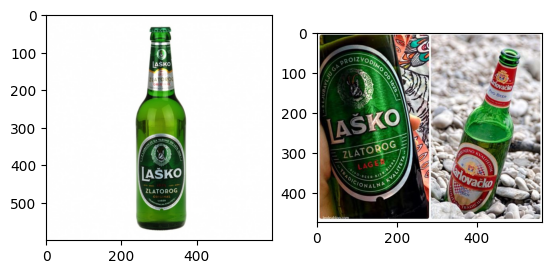

In [2]:
#img1 = cv2.imread('data/lasko.jpg')
#img2 = cv2.imread('data/two_beers.jpg')
img1=io.imread('https://github.com/hukim1112/DLCV_CLASS/raw/master/lecture4/data/lasko.jpg')
img2=io.imread('https://github.com/hukim1112/DLCV_CLASS/raw/master/lecture4/data/two_beers.jpg')


fig = plt.figure() # parallel display of images
fig.add_subplot(1,2,1)
plt.imshow(img1)
fig.add_subplot(1,2,2)
#plt.imshow(cv2.cvtColor(img2, cv2.COLOR_BGR2RGB))
plt.imshow(img2)

Number of keypoints in img1: 428
Number of keypoints in img2: 3274


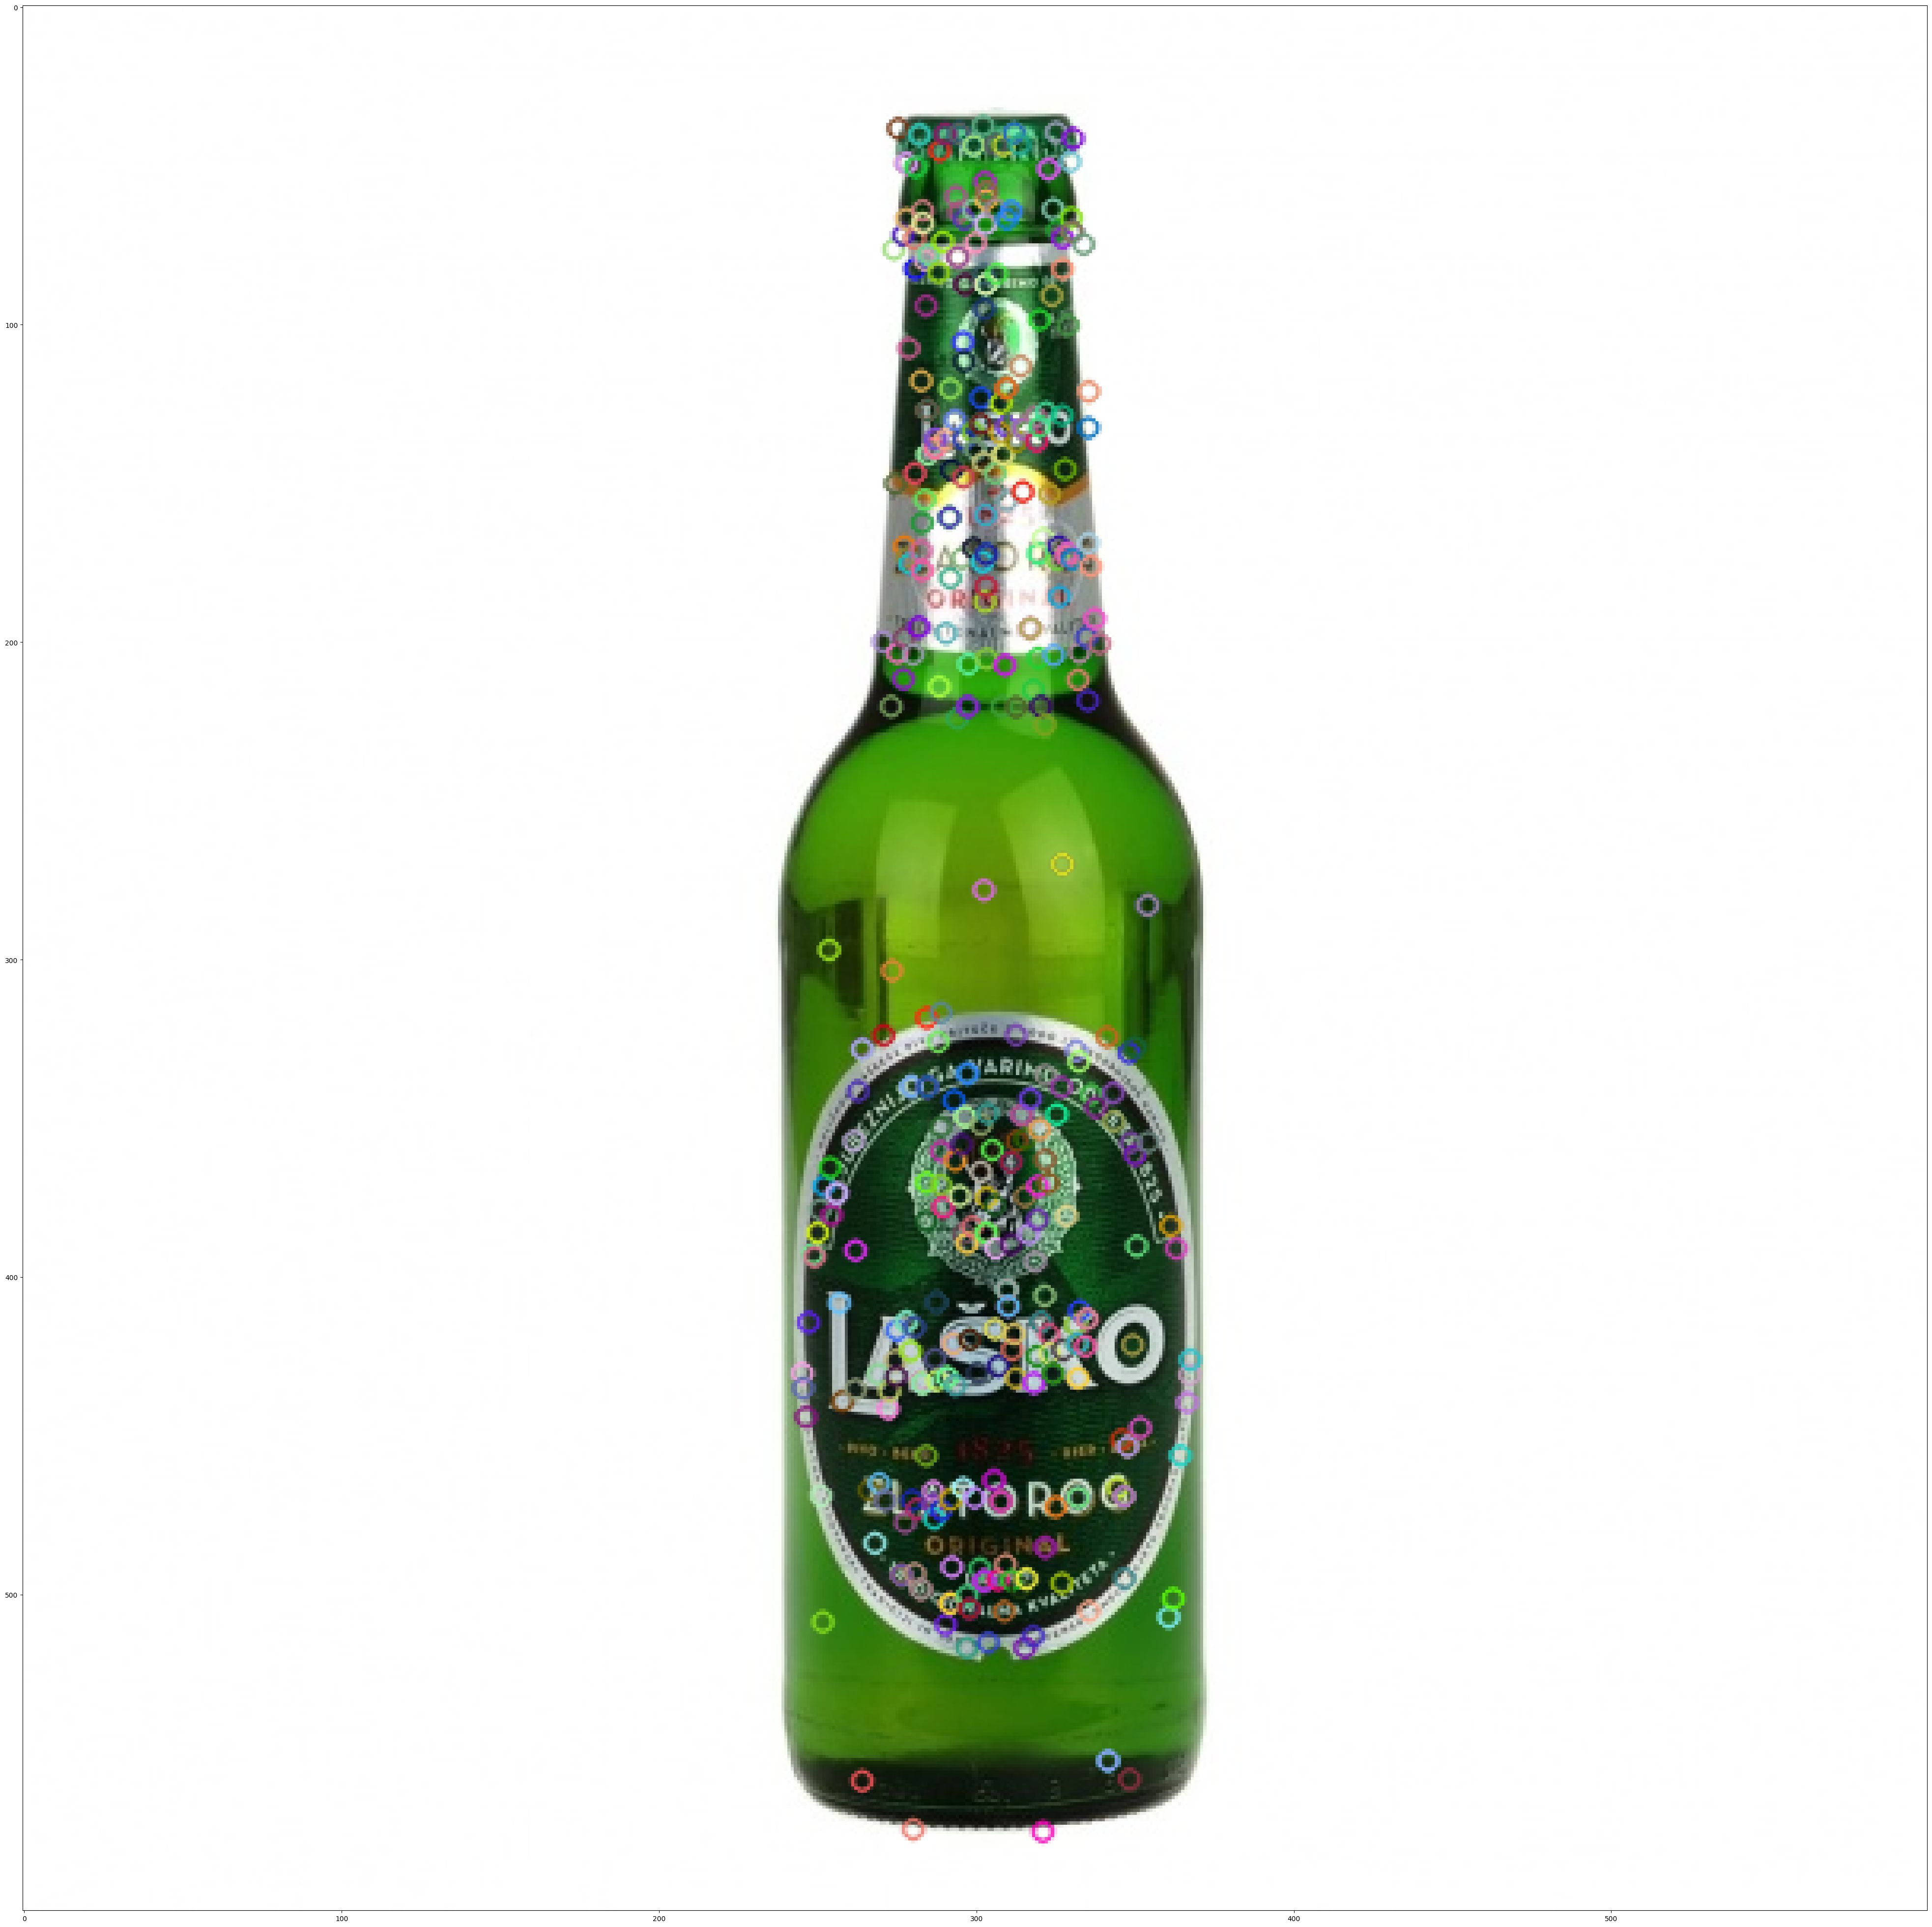

In [3]:
sift = cv2.SIFT_create()
kp1, des1 = sift.detectAndCompute(img1,None)
kp2, des2 = sift.detectAndCompute(img2,None)
print('Number of keypoints in img1: %d' % len(kp1))
print('Number of keypoints in img2: %d' % len(kp2))
img_with_kp = None
img_with_kp = cv2.drawKeypoints(img1,kp1,img_with_kp)
plt.figure(figsize=(50, 100))
plt.imshow(img_with_kp)

In [4]:
# BFMatcher with default params
bf = cv2.BFMatcher()
matches = bf.knnMatch(des1,des2, k=2)
print('Number of matches: %d' % len(matches))


Number of matches: 428


In [5]:
# store all the good matches as per Lowe's ratio test.
good = []
for m,n in matches:
    if m.distance < 0.7*n.distance:
      good.append([m])
print('Number of good matches: %d' % len(good))

#print descriptors of good matches, scale, orientation, and 128-dim vector

print('Descriptors of good matches')
for m in good:
    #print(des1[m[0].queryIdx], des2[m[0].trainIdx])
    print(kp1[m[0].queryIdx].size, kp1[m[0].queryIdx].angle, kp1[m[0].queryIdx].pt)
    print(kp2[m[0].trainIdx].size, kp2[m[0].trainIdx].angle, kp2[m[0].trainIdx].pt)
    print('')



Number of good matches: 28
Descriptors of good matches
3.7155635356903076 160.16151428222656 (251.0226287841797, 468.9343566894531)
8.206072807312012 166.54483032226562 (160.57395935058594, 161.99444580078125)

5.120211124420166 18.00670623779297 (269.04931640625, 430.6208190917969)
7.955498695373535 4.018745422363281 (53.94729995727539, 254.57359313964844)

3.106274366378784 359.9183349609375 (271.2373352050781, 470.43701171875)
4.9769206047058105 349.1288146972656 (75.64691925048828, 305.54522705078125)

3.8694846630096436 270.00787353515625 (272.267822265625, 441.655029296875)
6.335958957672119 256.6690368652344 (62.95402908325195, 270.76580810546875)

3.5292956829071045 341.8917236328125 (274.5711669921875, 426.251220703125)
6.064125061035156 340.0148010253906 (62.15157699584961, 243.85617065429688)

3.096276044845581 270.8729248046875 (274.7627868652344, 431.3622131347656)
5.10697603225708 262.74072265625 (65.08148956298828, 251.79774475097656)

1.9064552783966064 166.280288696289

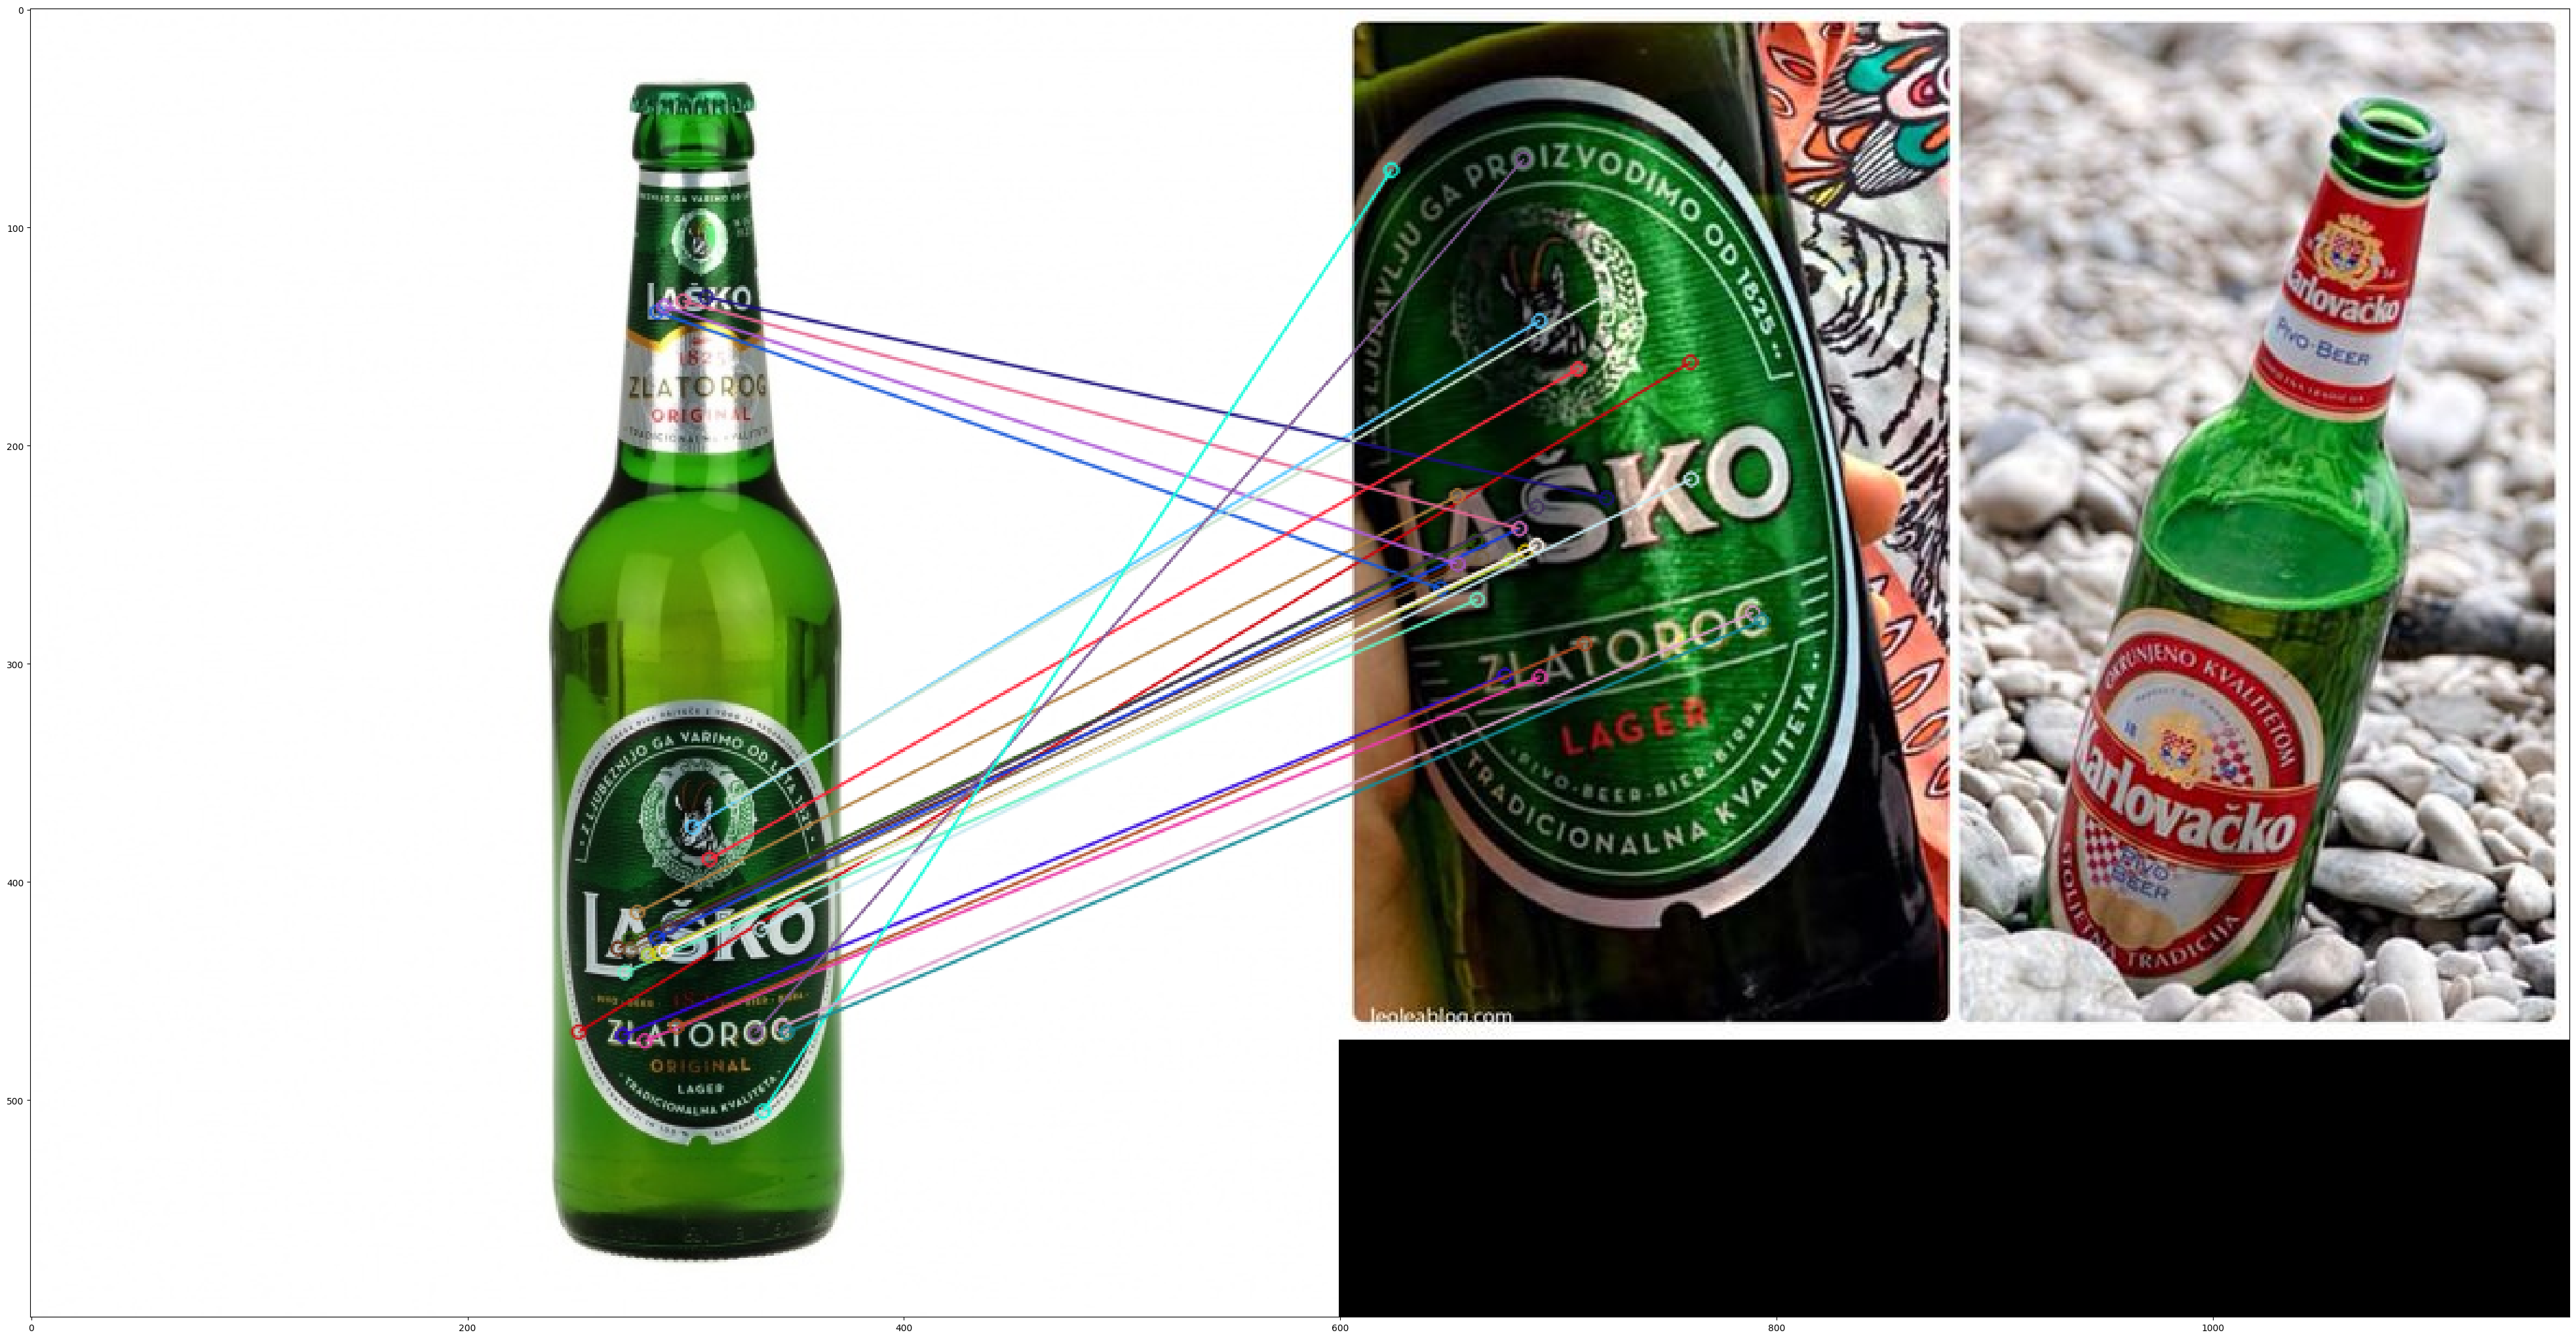

In [ ]:
img3 = None
img3 = cv2.drawMatchesKnn(img1,kp1,img2,kp2,good,img3,flags=2)
plt.figure(figsize=(50, 100))
plt.imshow(img3)

In [ ]:
print(len(kp1))
print(kp1[0].pt[0] , kp1[0].pt[1], kp1[1].pt[0] , kp1[1].pt[1])
print(des1.shape)
print(des1[0])
print(len(kp2))
print(des2.shape)
print(des2[0])

428
245.11585998535156 430.2926025390625 245.43663024902344 435.05078125
(428, 128)
[ 68.   7.   0.   3.  28.   0.   0.   1. 154.  17.   0.   0.   6.   1.
   0.   0.  74.   1.   0.   0.  35.   5.   0.   1. 154.   0.   0.   0.
   1.   0.   0.   3.  84.   6.   0.   2.  36.   0.   0.   0. 154.  17.
   0.   0.   5.   1.   1.   2. 101.   2.   0.   0.  45.   9.   1.   3.
 154.   0.   0.   0.   1.   0.   0.   4.  73.  14.   0.   2.  37.   0.
   0.   0. 154.  27.   0.   0.   5.   1.   0.   1. 112.   3.   0.   0.
  51.   7.   0.   2. 154.   0.   0.   0.   2.   0.   0.   2.  54.   4.
   0.   1.  30.   1.   0.   1. 154.  17.   0.   0.   3.   0.   0.   0.
  97.   3.   0.   0.  40.   5.   0.   1. 154.   0.   0.   0.   2.   0.
   0.   2.]
3274
(3274, 128)
[ 50.  17.   0.   0.   0.   0.   0.   0. 111.  15.   0.   0.   0.   1.
   1.   8. 169.  10.   0.   0.   0.   0.   0.   7.  51.   1.   0.   0.
   0.   0.   0.   1.  65.  11.   0.   0.   0.   0.   0.   2. 126.  30.
   1.   0.   0.   0.   5.  10. 169.

In [6]:

print(matches[0][0].queryIdx, matches[0][0].trainIdx,matches[0][1].trainIdx,matches[0][0].distance,matches[0][1].distance)

0 1427 1652 227.71034240722656 251.43588256835938
